In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Download NLP resources
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# Load CSV file
df = pd.read_csv("county-data-from-courts.csv")

# Display first rows
df.head()

,county,petitions_filed,petitions_percapita,petitions_dismissed,care_agreements,care_plans,graduations,data_as_of,notes
0,Judicial Council of California,2421,NaN,1090,514,14,NaN,2025-07-31,dismissal can occur at almost any point in the...
1,Alameda,125,9.5,16,38,0,0,2025-08-11,NaN
2,Alpine,0,0.0,0,0,0,0,2025-08-13,NaN
3,Amador,11,32.9,3,NaN,NaN,NaN,2025-08-01,NaN
4,Butte,17,10.3,*,*,0,0,2025-08-27,NaN


In [3]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   county               56 non-null     str    
 1   petitions_filed      56 non-null     str    
 2   petitions_percapita  51 non-null     float64
 3   petitions_dismissed  52 non-null     str    
 4   care_agreements      49 non-null     str    
 5   care_plans           43 non-null     str    
 6   graduations          35 non-null     str    
 7   data_as_of           55 non-null     str    
 8   notes                11 non-null     str    
dtypes: float64(1), str(8)
memory usage: 6.0 KB


In [4]:
# Separate numeric and text columns

numeric_cols = df.select_dtypes(include=['int64','float64']).columns
text_cols = df.select_dtypes(include=['object']).columns

print("Numeric columns:")
print(list(numeric_cols))

print("\nText columns:")
print(list(text_cols))

Numeric columns:
['petitions_percapita']

Text columns:
['county', 'petitions_filed', 'petitions_dismissed', 'care_agreements', 'care_plans', 'graduations', 'data_as_of', 'notes']


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_66289/679230880.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include=['object']).columns


In [5]:
# Fill missing text values
df[text_cols] = df[text_cols].fillna("")

# Combine all text columns into one column
df["combined_text"] = df[text_cols].apply(
    lambda x: " ".join(x.astype(str)),
    axis=1
)

df["combined_text"].head()

0    Judicial Council of California 2421 1090 514 1...
1                    Alameda 125 16 38 0 0 2025-08-11 
2                         Alpine 0 0 0 0 0 2025-08-13 
3                           Amador 11 3    2025-08-01 
4                         Butte 17 * * 0 0 2025-08-27 
Name: combined_text, dtype: str

In [6]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    
    words = text.split()
    words = [
        word for word in words 
        if word not in stop_words
    ]
    
    return " ".join(words)


df["clean_text"] = df["combined_text"].apply(clean_text)

df["clean_text"].head()

0    judicial council california dismissal occur al...
1                                              alameda
2                                               alpine
3                                               amador
4                                                butte
Name: clean_text, dtype: str

In [7]:
tfidf = TfidfVectorizer(
    max_features=1000
)

text_features = tfidf.fit_transform(
    df["clean_text"]
)

text_features.shape

(56, 97)

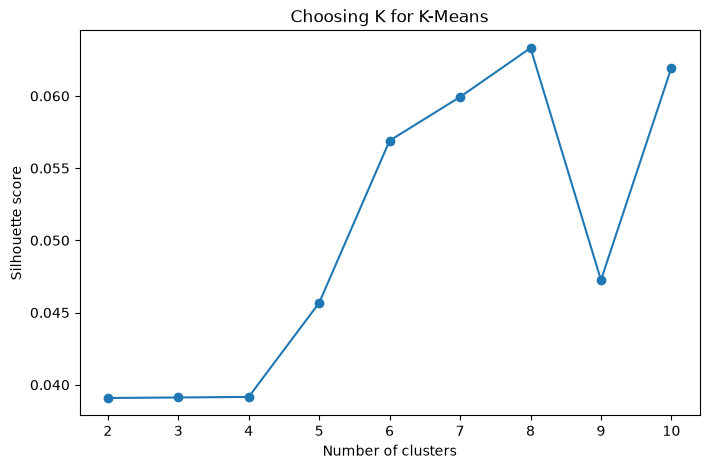

In [8]:
scores = []

K_range = range(2,11)

for k in K_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(text_features)
    
    score = silhouette_score(
        text_features,
        labels
    )
    
    scores.append(score)


plt.figure(figsize=(8,5))
plt.plot(K_range, scores, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("Choosing K for K-Means")
plt.show()

In [9]:
k = 5

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(
    text_features
)

df.head()

,county,petitions_filed,petitions_percapita,petitions_dismissed,care_agreements,care_plans,graduations,data_as_of,notes,combined_text,clean_text,cluster
0,Judicial Council of California,2421,NaN,1090,514,14,,2025-07-31,dismissal can occur at almost any point in the...,Judicial Council of California 2421 1090 514 1...,judicial council california dismissal occur al...,0
1,Alameda,125,9.5,16,38,0,0,2025-08-11,,Alameda 125 16 38 0 0 2025-08-11,alameda,0
2,Alpine,0,0.0,0,0,0,0,2025-08-13,,Alpine 0 0 0 0 0 2025-08-13,alpine,0
3,Amador,11,32.9,3,,,,2025-08-01,,Amador 11 3 2025-08-01,amador,0
4,Butte,17,10.3,*,*,0,0,2025-08-27,,Butte 17 * * 0 0 2025-08-27,butte,0


In [10]:
df["cluster"].value_counts()

cluster
0    45
2     7
3     2
1     1
4     1
Name: count, dtype: int64

In [11]:
terms = tfidf.get_feature_names_out()

for cluster_num in range(k):
    
    center = kmeans.cluster_centers_[cluster_num]
    
    top_words = [
        terms[i]
        for i in center.argsort()[-10:]
    ]
    
    print(
        f"\nCluster {cluster_num}:"
    )
    print(top_words)


Cluster 0:
['mariposa', 'mendocino', 'merced', 'mono', 'monterey', 'napa', 'nevada', 'plumas', 'yuba', 'san']

Cluster 1:
['extended', 'eventually', 'doesnt', 'dismissed', 'dismissals', 'dismissal', 'lake', 'yuba', 'el', 'dorado']

Cluster 2:
['tuolumne', 'shasta', 'sonoma', 'imperial', 'kings', 'said', 'graduations', 'track', 'doesnt', 'court']

Cluster 3:
['el', 'dorado', 'doesnt', 'dismissed', 'dismissals', 'fresno', 'yuba', 'clara', 'barbara', 'santa']

Cluster 4:
['eventually', 'el', 'dorado', 'doesnt', 'dismissed', 'dismissals', 'dismissal', 'fresno', 'yuba', 'sierra']


In [12]:
pca = PCA(
    n_components=2
)

reduced = pca.fit_transform(
    text_features.toarray()
)

visual_df = pd.DataFrame(
    reduced,
    columns=["PC1","PC2"]
)

visual_df["cluster"] = df["cluster"]

visual_df.head()

,PC1,PC2,cluster
0,-0.018587,-0.088555,0
1,-0.101083,-0.078238,0
2,-0.101083,-0.078238,0
3,-0.101083,-0.078238,0
4,-0.101083,-0.078238,0


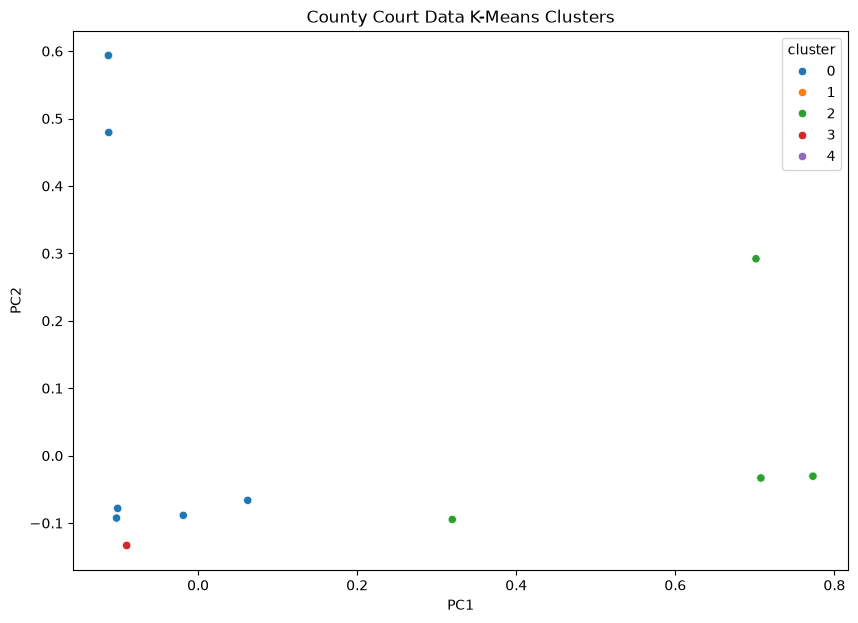

In [13]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=visual_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10"
)

plt.title(
    "County Court Data K-Means Clusters"
)

plt.show()

In [14]:
# Scale numeric data

scaler = StandardScaler()

numeric_features = scaler.fit_transform(
    df[numeric_cols].fillna(0)
)


# Combine numeric + NLP features

from scipy.sparse import hstack

combined_features = hstack(
    [
        text_features,
        numeric_features
    ]
)


kmeans_numeric = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["combined_cluster"] = (
    kmeans_numeric.fit_predict(
        combined_features
    )
)

df.head()

,county,petitions_filed,petitions_percapita,petitions_dismissed,care_agreements,care_plans,graduations,data_as_of,notes,combined_text,clean_text,cluster,combined_cluster
0,Judicial Council of California,2421,NaN,1090,514,14,,2025-07-31,dismissal can occur at almost any point in the...,Judicial Council of California 2421 1090 514 1...,judicial council california dismissal occur al...,0,1
1,Alameda,125,9.5,16,38,0,0,2025-08-11,,Alameda 125 16 38 0 0 2025-08-11,alameda,0,3
2,Alpine,0,0.0,0,0,0,0,2025-08-13,,Alpine 0 0 0 0 0 2025-08-13,alpine,0,1
3,Amador,11,32.9,3,,,,2025-08-01,,Amador 11 3 2025-08-01,amador,0,2
4,Butte,17,10.3,*,*,0,0,2025-08-27,,Butte 17 * * 0 0 2025-08-27,butte,0,3
